In [8]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from lo_tools import Lfun, zrfun, zfun
Ldir = Lfun.Lstart()

In [ ]:
#folder = Path("../../LO_roms/ae0_tgrdnt_xa0/f2020.01.05/")
folder = Path("../../LO_roms/ae0_tgrdnt_xa0/f2020.01.12/")
flist = sorted(folder.glob("ocean_his_*.nc"))

ds = xr.open_mfdataset(flist, combine="by_coords")

# 24-hr mean
ds24 = ds.mean(dim="ocean_time")
print(ds24)

/tmp/ipykernel_396473/2075415169.py:5: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset(flist, combine="by_coords")


<xarray.Dataset> Size: 137MB
Dimensions:         (tracer: 2, boundary: 4, s_rho: 30, s_w: 31, eta_rho: 386,
                     xi_rho: 348, eta_u: 386, xi_u: 347, eta_v: 385, xi_v: 348,
                     eta_psi: 385, xi_psi: 347)
Coordinates:
  * s_rho           (s_rho) float64 240B -0.9833 -0.95 ... -0.05 -0.01667
  * s_w             (s_w) float64 248B -1.0 -0.9667 -0.9333 ... -0.03333 0.0
    lon_rho         (eta_rho, xi_rho) float64 1MB dask.array<chunksize=(386, 348), meta=np.ndarray>
    lat_rho         (eta_rho, xi_rho) float64 1MB dask.array<chunksize=(386, 348), meta=np.ndarray>
    lon_u           (eta_u, xi_u) float64 1MB dask.array<chunksize=(386, 347), meta=np.ndarray>
    lat_u           (eta_u, xi_u) float64 1MB dask.array<chunksize=(386, 347), meta=np.ndarray>
    lon_v           (eta_v, xi_v) float64 1MB dask.array<chunksize=(385, 348), meta=np.ndarray>
    lat_v           (eta_v, xi_v) float64 1MB dask.array<chunksize=(385, 348), meta=np.ndarray>
    lon_psi     

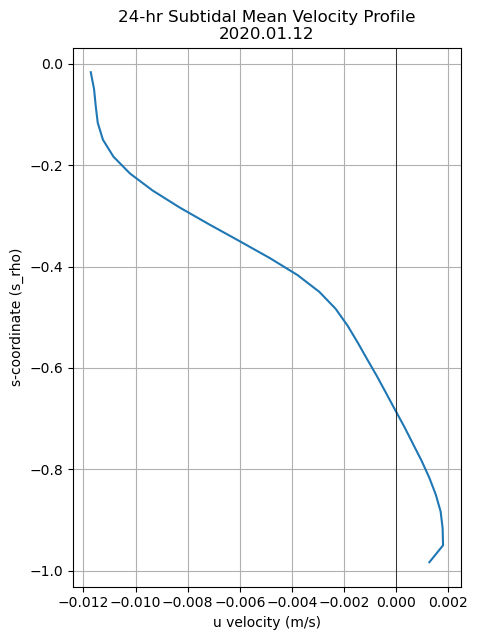

In [35]:
u_prof = ds24.u.mean(dim=("eta_u", "xi_u"))

plt.figure(figsize=(5,7))

plt.plot(u_prof.values, ds24.s_rho.values, label="u")

plt.axvline(0, color="k", lw=0.5)
plt.xlabel("u velocity (m/s)")
plt.ylabel("s-coordinate (s_rho)")
plt.title("24-hr Subtidal Mean Velocity Profile\n2020.01.12")
plt.grid(True)

plt.show()

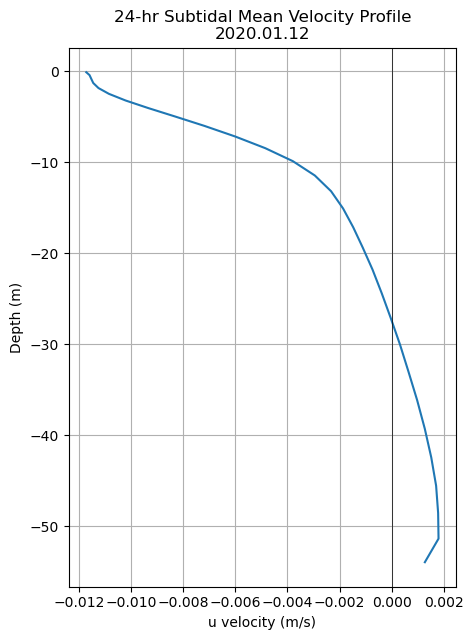

In [ ]:
# convert to meters
# for more physically meaninful, we would want to convert to depth coordinates before averaging horizontally.

from lo_tools import zrfun

# get needed fields
h = ds24.h.values                # (eta_rho, xi_rho)
zeta = ds24.zeta.values          # (eta_rho, xi_rho)

fn = folder / "ocean_his_0001.nc"
G, S, T = zrfun.get_basic_info(fn)

# compute z_rho in meters (negative down)
z_rho = zrfun.get_z(h, zeta, S, only_rho=True) 

# domain-mean depth profile (1D)
z_prof = np.nanmean(z_rho, axis=(1,2))

u_prof = ds24.u.mean(dim=("eta_u", "xi_u"))

plt.figure(figsize=(5,7))

plt.plot(u_prof.values, z_prof, label="u")

plt.axvline(0, color="k", lw=0.5)
plt.xlabel("u velocity (m/s)")
plt.ylabel("Depth (m)")
plt.title("24-hr Subtidal Mean Velocity Profile\n2020.01.12")
plt.grid(True)

plt.show()

/tmp/ipykernel_396473/4133245883.py:30: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset(flist, combine="by_coords")
/tmp/ipykernel_396473/4133245883.py:30: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset(flist, combine="by_coords")
/tmp/ipykernel_396473/4133245883.py:30

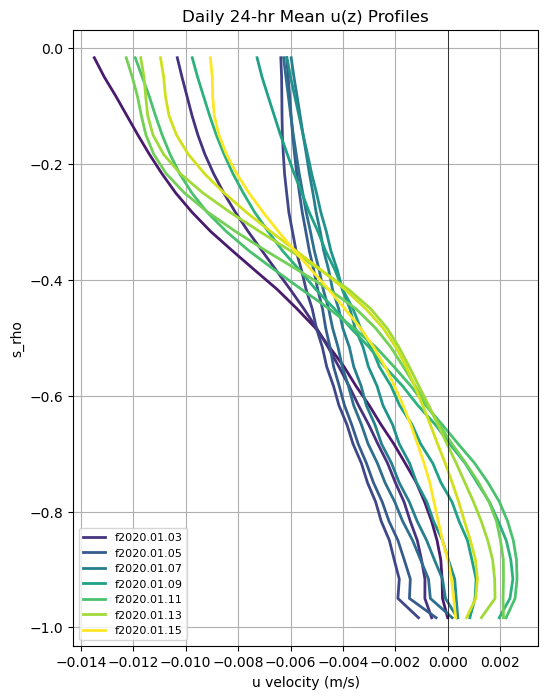

In [24]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import matplotlib.cm as cm
import matplotlib.colors as colors
from matplotlib.lines import Line2D

base_dir = Path("../../LO_roms/ae0_tgrdnt_xa0/")
day_folders = sorted(base_dir.glob("f2020.01.*"))

# viridis colormap setup
cmap = cm.viridis
norm = colors.Normalize(vmin=0, vmax=len(day_folders)-1)

plt.figure(figsize=(6,8))

handles = []
labels = []

for i, folder in enumerate(day_folders):
    
    if folder.name == "f2020.01.01":
        continue

    flist = sorted(folder.glob("ocean_his_*.nc"))
    if len(flist) == 0:
        continue

    ds = xr.open_mfdataset(flist, combine="by_coords")
    ds24 = ds.mean(dim="ocean_time")

    # domain mean u profile
    u_prof = ds24.u.mean(dim=("eta_u", "xi_u"))

    col = cmap(norm(i))

    plt.plot(u_prof.values, ds24.s_rho.values, color=col, lw=2)

    # add to legend 
    if i % 2 == 0:
        handles.append(Line2D([0], [0], color=col, lw=2))
        labels.append(folder.name)

    ds.close()

plt.axvline(0, color='k', lw=0.5)
plt.xlabel("u velocity (m/s)")
plt.ylabel("s_rho")
plt.title("Daily 24-hr Mean u(z) Profiles")
plt.grid(True)

plt.legend(handles, labels, fontsize=8, loc="best")
plt.show()